In [1]:
# ============================================================
# PHASE 13 — PAIRED STATISTICAL CALIBRATION + CLAIM CALIBRATION
# ============================================================
# Goals:
# 1. Run paired tests on repeated-split seed deltas:
#    delta_i = metric_DNABERT2(seed_i) - metric_handcrafted(seed_i)
# 2. Use:
#    - Wilcoxon signed-rank test as primary paired test
#    - Paired t-test as supportive test
#    - Exact sign test for win-count formalisation
#    - BH-FDR across 4 metrics
# 3. Calibrate biological claims:
#    - define moved-in/out comparator
#    - report moved-in baseline clearly
#    - report moved-out FDR clearly
#    - classify biological evidence as hypothesis-generating if FDR-borderline
# 4. Generate report-ready tables and text for revised Sections 10–11.
# ============================================================

import warnings
from pathlib import Path
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, ttest_rel, t
from scipy.stats import binomtest

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE11_DIR = PROJECT_DIR / "model" / "phase11_repeated_split_seed_robustness"
PHASE12_DIR = PROJECT_DIR / "model" / "phase12_random_gene_set_enrichment_baseline"

PHASE11_RESULT_DIR = PHASE11_DIR / "results"
PHASE12_RESULT_DIR = PHASE12_DIR / "results"

PHASE13_DIR = PROJECT_DIR / "model" / "phase13_statistical_and_claim_calibration"
RESULT_DIR = PHASE13_DIR / "results"
FIGURE_DIR = PHASE13_DIR / "figures"
EXCEL_DIR = PHASE13_DIR / "excel"
REPORT_DIR = PHASE13_DIR / "reports"

for folder in [PHASE13_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 13 output:", PHASE13_DIR)

Mounted at /content/drive
Phase 13 output: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration


In [2]:
# ============================================================
# LOAD REQUIRED INPUTS
# ============================================================

def read_csv_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    print("Loaded:", path)
    return pd.read_csv(path)

# Phase 11 repeated-split raw results
phase11_raw_path = PHASE11_RESULT_DIR / "phase11_repeated_split_raw_model_results.csv"
run_results_df = read_csv_required(phase11_raw_path)

# Phase 11 existing summary and paired comparison, if available
phase11_summary_path = PHASE11_RESULT_DIR / "phase11_repeated_split_mean_sd_summary.csv"
phase11_existing_paired_path = PHASE11_RESULT_DIR / "phase11_paired_comparison_across_seeds.csv"

phase11_summary_df = read_csv_required(phase11_summary_path)
phase11_existing_paired_df = read_csv_required(phase11_existing_paired_path)

# Phase 12 biological random baseline
phase12_focus_path = PHASE12_RESULT_DIR / "phase12_focus_observed_vs_random_main_models_themes.csv"
phase12_compact_path = PHASE12_RESULT_DIR / "phase12_publication_style_random_baseline_table.csv"
phase12_hand_vs_dna_path = PHASE12_RESULT_DIR / "phase12_handcrafted_vs_dnabert2_random_baseline_comparison.csv"
phase12_moved_path = PHASE12_RESULT_DIR / "phase12_dnabert2_moved_in_out_random_baseline.csv"
phase12_claims_path = PHASE12_RESULT_DIR / "phase12_final_interpretation_claims.csv"
phase12_repro_path = PHASE12_RESULT_DIR / "phase12_reproducibility_table.csv"

focus_df = read_csv_required(phase12_focus_path)
compact_publication_df = read_csv_required(phase12_compact_path)
hand_vs_dna_random_df = read_csv_required(phase12_hand_vs_dna_path)
moved_random_df = read_csv_required(phase12_moved_path)
phase12_claims_df = read_csv_required(phase12_claims_path)
phase12_reproducibility_df = read_csv_required(phase12_repro_path)

print("\nPhase 11 raw results:")
display(run_results_df.head())

print("\nPhase 12 moved random baseline:")
display(moved_random_df.head())

Loaded: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_raw_model_results.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_mean_sd_summary.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_paired_comparison_across_seeds.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_focus_observed_vs_random_main_models_themes.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_publication_style_random_baseline_table.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_handcrafted_vs_dnabert2_random_baseline_comparison.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrich

,seed,model_key,model_description,n_train,n_val,n_test,n_features,selected_threshold,validation_threshold_metric,validation_threshold_metric_value,roc_auc,pr_auc,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,11,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,1264,271,271,1024,-0.1757,mcc,0.3320,0.7534,0.7324,-0.1757,0.6531,0.6250,0.7721,0.5333,0.6908,0.3146,72,63,31,105
1,11,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,1264,271,271,356,0.1170,mcc,0.1607,0.6518,0.6391,0.1170,0.6162,0.6404,0.5368,0.6963,0.5840,0.2360,94,41,63,73
2,11,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,1264,271,271,1380,-0.0941,mcc,0.3165,0.7586,0.7118,-0.0941,0.7011,0.6752,0.7794,0.6222,0.7235,0.4068,84,51,30,106
3,11,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,1264,271,271,1792,-0.3005,mcc,0.3351,0.7578,0.7192,-0.3005,0.7011,0.6536,0.8603,0.5407,0.7429,0.4234,73,62,19,117
4,22,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,1264,271,271,1024,-0.1192,mcc,0.3611,0.6958,0.6855,-0.1192,0.6384,0.6234,0.7059,0.5704,0.6621,0.2789,77,58,40,96



Phase 12 moved random baseline:


,gene_set_name,top_n,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,empirical_p_bh_fdr,significant_fdr_0p05
0,DNABERT2_moved_in_top50,50,11,insulin_signalling,0,0.0,NaN,0.039,0.1937,0.0,0,1,0.0,1.0,-0.2014,0.0,1.0,False,1000,1.0,False
1,DNABERT2_moved_in_top50,50,11,glucose_metabolism,0,0.0,NaN,0.123,0.3435,0.0,0,2,0.0,1.0,-0.3581,0.0,1.0,False,1000,1.0,False
2,DNABERT2_moved_in_top50,50,11,beta_cell_biology,0,0.0,NaN,0.378,0.5912,0.0,0,4,0.0,2.0,-0.6394,0.0,1.0,False,1000,1.0,False
3,DNABERT2_moved_in_top50,50,11,mitochondrial_function,0,0.0,NaN,0.414,0.6124,0.0,0,4,0.0,2.0,-0.6761,0.0,1.0,False,1000,1.0,False
4,DNABERT2_moved_in_top50,50,11,oxidative_phosphorylation,0,0.0,NaN,0.411,0.6168,0.0,0,4,0.0,2.0,-0.6663,0.0,1.0,False,1000,1.0,False


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

MODEL_A = "Multimodal_handcrafted"
MODEL_B = "Multimodal_DNABERT2"

# delta = DNABERT2 - handcrafted
PAIR_LABEL = "DNABERT2_minus_handcrafted"

METRICS = ["pr_auc", "mcc", "roc_auc", "f1"]

METRIC_ROLE = {
    "pr_auc": "Primary ranking metric",
    "mcc": "Primary threshold-dependent metric",
    "roc_auc": "Secondary global ranking metric",
    "f1": "Secondary threshold-dependent metric"
}

METRIC_DISPLAY = {
    "pr_auc": "PR-AUC",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
    "f1": "F1"
}

print("Paired comparison:", MODEL_B, "-", MODEL_A)
print("Metrics:", METRICS)

Paired comparison: Multimodal_DNABERT2 - Multimodal_handcrafted
Metrics: ['pr_auc', 'mcc', 'roc_auc', 'f1']


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def bh_fdr_correction(pvals):
    """
    Benjamini-Hochberg FDR correction.
    Returns adjusted p-values in the original order.
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    adjusted_ranked = ranked * n / (np.arange(1, n + 1))
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.minimum(adjusted_ranked, 1.0)

    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = adjusted_ranked

    return adjusted


def bootstrap_mean_ci(values, n_boot=10000, ci=0.95, seed=42):
    """
    Bootstrap CI for mean delta across seeds.
    """
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)

    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means.append(np.mean(sample))

    alpha = 1 - ci
    lower = np.percentile(boot_means, 100 * alpha / 2)
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return lower, upper


def t_based_mean_ci(values, ci=0.95):
    """
    t-based CI for mean delta.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = np.mean(values)
    sd = np.std(values, ddof=1)
    se = sd / np.sqrt(n)

    alpha = 1 - ci
    crit = t.ppf(1 - alpha / 2, df=n - 1)

    lower = mean - crit * se
    upper = mean + crit * se

    return lower, upper


def cohen_dz(values):
    """
    Cohen's dz for paired differences.
    dz = mean(delta) / sd(delta)
    """
    values = np.asarray(values, dtype=float)
    sd = np.std(values, ddof=1)
    if sd == 0:
        return np.nan
    return np.mean(values) / sd


def rank_biserial_from_wilcoxon(values):
    """
    Matched-pairs rank-biserial correlation.
    Computed as:
    r_rb = (W_plus - W_minus) / total_rank_sum

    Handles zero differences by removing zeros.
    """
    values = np.asarray(values, dtype=float)
    nonzero = values[values != 0]

    if len(nonzero) == 0:
        return 0.0

    abs_vals = np.abs(nonzero)
    ranks = pd.Series(abs_vals).rank(method="average").values

    w_plus = np.sum(ranks[nonzero > 0])
    w_minus = np.sum(ranks[nonzero < 0])
    total = np.sum(ranks)

    if total == 0:
        return np.nan

    return (w_plus - w_minus) / total


def exact_sign_test_p(n_positive, n_negative):
    """
    Two-sided exact sign test using binomial test.
    Ties are excluded.
    """
    n = n_positive + n_negative

    if n == 0:
        return np.nan

    result = binomtest(
        k=n_positive,
        n=n,
        p=0.5,
        alternative="two-sided"
    )

    return result.pvalue


def interpretation_for_paired_row(row):
    """
    Generate calibrated interpretation.
    """
    metric = row["metric"]
    mean_delta = row["mean_delta"]
    fdr_p = row["wilcoxon_p_bh_fdr"]

    if metric == "pr_auc":
        if abs(mean_delta) < 0.005:
            return (
                "PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. "
                "This supports comparable primary ranking performance, not DNABERT-2 superiority."
            )

    if fdr_p < 0.05:
        if mean_delta > 0:
            return (
                "DNABERT-2 shows a statistically supported paired improvement after BH correction."
            )
        elif mean_delta < 0:
            return (
                "Handcrafted multimodal shows a statistically supported paired improvement after BH correction."
            )

    if mean_delta > 0:
        return (
            "DNABERT-2 is numerically higher, but the paired difference is not statistically significant "
            "after BH correction. Interpret as directional, not established."
        )

    if mean_delta < 0:
        return (
            "Handcrafted multimodal is numerically higher, but the paired difference is not statistically significant "
            "after BH correction. Interpret cautiously."
        )

    return "No paired difference observed."

In [5]:
# ============================================================
# BUILD PER-SEED DELTA TABLE
# delta_i = DNABERT2(seed_i) - Handcrafted(seed_i)
# ============================================================

delta_records = []

for metric in METRICS:
    a = run_results_df[
        run_results_df["model_key"] == MODEL_A
    ][["seed", metric]].rename(columns={metric: f"{MODEL_A}_{metric}"})

    b = run_results_df[
        run_results_df["model_key"] == MODEL_B
    ][["seed", metric]].rename(columns={metric: f"{MODEL_B}_{metric}"})

    merged = a.merge(b, on="seed", how="inner")

    assert merged.shape[0] > 0, f"No paired seeds found for {metric}"

    merged["metric"] = metric
    merged["metric_display"] = METRIC_DISPLAY[metric]
    merged["metric_role"] = METRIC_ROLE[metric]
    merged["delta_dnabert2_minus_handcrafted"] = (
        merged[f"{MODEL_B}_{metric}"] - merged[f"{MODEL_A}_{metric}"]
    )
    merged["direction"] = np.where(
        merged["delta_dnabert2_minus_handcrafted"] > 0,
        "DNABERT2_better",
        np.where(
            merged["delta_dnabert2_minus_handcrafted"] < 0,
            "Handcrafted_better",
            "tie"
        )
    )

    delta_records.append(merged)

per_seed_delta_df = pd.concat(delta_records, ignore_index=True)
per_seed_delta_df = round_numeric_columns(per_seed_delta_df, 6)

display(per_seed_delta_df)

per_seed_delta_path = RESULT_DIR / "phase13_per_seed_deltas_dnabert2_minus_handcrafted.csv"
per_seed_delta_df.to_csv(per_seed_delta_path, index=False)

print("Saved:", per_seed_delta_path)

,seed,Multimodal_handcrafted_pr_auc,Multimodal_DNABERT2_pr_auc,metric,metric_display,metric_role,delta_dnabert2_minus_handcrafted,direction,Multimodal_handcrafted_mcc,Multimodal_DNABERT2_mcc,Multimodal_handcrafted_roc_auc,Multimodal_DNABERT2_roc_auc,Multimodal_handcrafted_f1,Multimodal_DNABERT2_f1
0,11,0.7118,0.7192,pr_auc,PR-AUC,Primary ranking metric,0.0074,DNABERT2_better,NaN,NaN,NaN,NaN,NaN,NaN
1,22,0.7104,0.6978,pr_auc,PR-AUC,Primary ranking metric,-0.0126,Handcrafted_better,NaN,NaN,NaN,NaN,NaN,NaN
2,33,0.6918,0.6963,pr_auc,PR-AUC,Primary ranking metric,0.0045,DNABERT2_better,NaN,NaN,NaN,NaN,NaN,NaN
3,44,0.7607,0.7687,pr_auc,PR-AUC,Primary ranking metric,0.0080,DNABERT2_better,NaN,NaN,NaN,NaN,NaN,NaN
4,55,0.7875,0.7795,pr_auc,PR-AUC,Primary ranking metric,-0.0080,Handcrafted_better,NaN,NaN,NaN,NaN,NaN,NaN
5,66,0.7259,0.7256,pr_auc,PR-AUC,Primary ranking metric,-0.0003,Handcrafted_better,NaN,NaN,NaN,NaN,NaN,NaN
6,77,0.7663,0.7716,pr_auc,PR-AUC,Primary ranking metric,0.0053,DNABERT2_better,NaN,NaN,NaN,NaN,NaN,NaN
7,88,0.6918,0.7059,pr_auc,PR-AUC,Primary ranking metric,0.0141,DNABERT2_better,NaN,NaN,NaN,NaN,NaN,NaN
8,99,0.6973,0.6880,pr_auc,PR-AUC,Primary ranking metric,-0.0093,Handcrafted_better,NaN,NaN,NaN,NaN,NaN,NaN
9,111,0.7043,0.7038,pr_auc,PR-AUC,Primary ranking metric,-0.0005,Handcrafted_better,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_per_seed_deltas_dnabert2_minus_handcrafted.csv


In [6]:
# ============================================================
# PAIRED TESTS PER METRIC
# ============================================================

paired_records = []

for metric in METRICS:
    sub = per_seed_delta_df[per_seed_delta_df["metric"] == metric].copy()
    deltas = sub["delta_dnabert2_minus_handcrafted"].astype(float).values

    n = len(deltas)
    n_dnabert2_better = int(np.sum(deltas > 0))
    n_handcrafted_better = int(np.sum(deltas < 0))
    n_ties = int(np.sum(deltas == 0))

    mean_delta = float(np.mean(deltas))
    median_delta = float(np.median(deltas))
    sd_delta = float(np.std(deltas, ddof=1))
    min_delta = float(np.min(deltas))
    max_delta = float(np.max(deltas))

    # t-based and bootstrap CI
    t_ci_low, t_ci_high = t_based_mean_ci(deltas, ci=0.95)
    boot_ci_low, boot_ci_high = bootstrap_mean_ci(deltas, n_boot=10000, ci=0.95, seed=42)

    # Wilcoxon signed-rank test
    # If all deltas are zero, wilcoxon fails.
    try:
        wilcoxon_result = wilcoxon(
            deltas,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            mode="auto"
        )
        wilcoxon_stat = float(wilcoxon_result.statistic)
        wilcoxon_p = float(wilcoxon_result.pvalue)
    except Exception as e:
        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan
        print("Wilcoxon failed for", metric, "|", e)

    # Paired t-test on raw model values
    # Equivalent to one-sample t-test on deltas.
    a_vals = sub[f"{MODEL_A}_{metric}"].astype(float).values
    b_vals = sub[f"{MODEL_B}_{metric}"].astype(float).values

    try:
        ttest_result = ttest_rel(b_vals, a_vals, alternative="two-sided")
        paired_t_stat = float(ttest_result.statistic)
        paired_t_p = float(ttest_result.pvalue)
    except Exception as e:
        paired_t_stat = np.nan
        paired_t_p = np.nan
        print("Paired t-test failed for", metric, "|", e)

    # Exact sign test
    sign_p = exact_sign_test_p(n_dnabert2_better, n_handcrafted_better)

    # Effect sizes
    dz = cohen_dz(deltas)
    rank_biserial = rank_biserial_from_wilcoxon(deltas)

    paired_records.append({
        "metric": metric,
        "metric_display": METRIC_DISPLAY[metric],
        "metric_role": METRIC_ROLE[metric],
        "n_paired_seeds": n,
        "mean_delta": mean_delta,
        "median_delta": median_delta,
        "sd_delta": sd_delta,
        "t_ci95_low": t_ci_low,
        "t_ci95_high": t_ci_high,
        "bootstrap_ci95_low": boot_ci_low,
        "bootstrap_ci95_high": boot_ci_high,
        "min_delta": min_delta,
        "max_delta": max_delta,
        "n_dnabert2_better": n_dnabert2_better,
        "n_handcrafted_better": n_handcrafted_better,
        "n_ties": n_ties,
        "wilcoxon_statistic": wilcoxon_stat,
        "wilcoxon_p": wilcoxon_p,
        "paired_t_statistic": paired_t_stat,
        "paired_t_p": paired_t_p,
        "exact_sign_test_p": sign_p,
        "cohen_dz": dz,
        "rank_biserial_correlation": rank_biserial,
        "delta_values": ";".join([f"{x:.6f}" for x in deltas])
    })

paired_stats_df = pd.DataFrame(paired_records)

# BH-FDR across four Wilcoxon p-values
paired_stats_df["wilcoxon_p_bh_fdr"] = bh_fdr_correction(paired_stats_df["wilcoxon_p"].values)
paired_stats_df["paired_t_p_bh_fdr"] = bh_fdr_correction(paired_stats_df["paired_t_p"].values)
paired_stats_df["sign_test_p_bh_fdr"] = bh_fdr_correction(paired_stats_df["exact_sign_test_p"].values)

paired_stats_df["wilcoxon_significant_fdr_0p05"] = paired_stats_df["wilcoxon_p_bh_fdr"] < 0.05
paired_stats_df["paired_t_significant_fdr_0p05"] = paired_stats_df["paired_t_p_bh_fdr"] < 0.05
paired_stats_df["sign_test_significant_fdr_0p05"] = paired_stats_df["sign_test_p_bh_fdr"] < 0.05

paired_stats_df["calibrated_interpretation"] = paired_stats_df.apply(
    interpretation_for_paired_row,
    axis=1
)

paired_stats_df = round_numeric_columns(paired_stats_df, 6)

display(paired_stats_df)

paired_stats_path = RESULT_DIR / "phase13_paired_seed_statistics_dnabert2_vs_handcrafted.csv"
paired_stats_df.to_csv(paired_stats_path, index=False)

print("Saved:", paired_stats_path)

,metric,metric_display,metric_role,n_paired_seeds,mean_delta,median_delta,sd_delta,t_ci95_low,t_ci95_high,bootstrap_ci95_low,bootstrap_ci95_high,min_delta,max_delta,n_dnabert2_better,n_handcrafted_better,n_ties,wilcoxon_statistic,wilcoxon_p,paired_t_statistic,paired_t_p,exact_sign_test_p,cohen_dz,rank_biserial_correlation,delta_values,wilcoxon_p_bh_fdr,paired_t_p_bh_fdr,sign_test_p_bh_fdr,wilcoxon_significant_fdr_0p05,paired_t_significant_fdr_0p05,sign_test_significant_fdr_0p05,calibrated_interpretation
0,pr_auc,PR-AUC,Primary ranking metric,10,0.00086,0.00210,0.008616,-0.005303,0.007023,-0.004190,0.005870,-0.0126,0.0141,5,5,0,26.5,0.943359,0.315644,0.759469,1.000000,0.099815,0.036364,0.007400;-0.012600;0.004500;0.008000;-0.008000;-0.000300;0.005300;0.014100;-0.009300;-0.000500,0.943359,0.759469,1.000000,False,False,False,"PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. This supports comparable primary ranking performance, not DNABERT-2 superiority."
1,mcc,MCC,Primary threshold-dependent metric,10,0.02708,0.02110,0.061226,-0.016718,0.070878,-0.008813,0.063260,-0.0689,0.1175,7,3,0,14.0,0.193359,1.398672,0.195414,0.343750,0.442299,0.490909,0.016600;-0.068900;-0.053500;0.039200;0.084600;0.020400;0.098800;0.021800;0.117500;-0.005700,0.257812,0.390828,0.458333,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
2,roc_auc,ROC-AUC,Secondary global ranking metric,10,0.01034,0.01155,0.012091,0.001690,0.018990,0.003030,0.017250,-0.0133,0.0283,8,2,0,6.0,0.027344,2.704246,0.024225,0.109375,0.855158,0.781818,-0.000800;0.008300;-0.013300;0.020900;0.005500;0.004300;0.019500;0.028300;0.014800;0.015900,0.109375,0.096899,0.218750,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
3,f1,F1,Secondary threshold-dependent metric,10,0.02363,0.01790,0.079495,-0.033238,0.080498,-0.021600,0.068161,-0.1392,0.1445,8,2,0,10.0,0.083984,0.939987,0.371766,0.109375,0.297250,0.636364,0.019400;-0.139200;0.010200;0.017200;0.018600;0.023500;0.143100;-0.005500;0.144500;0.004500,0.167969,0.495688,0.218750,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_paired_seed_statistics_dnabert2_vs_handcrafted.csv


In [7]:
# ============================================================
# REPORT-READY PAIRED STATISTICS TABLE
# ============================================================

report_paired_records = []

for _, row in paired_stats_df.iterrows():
    report_paired_records.append({
        "Metric": f"{row['metric_display']} ({row['metric_role']})",
        "Mean Δ D2−HC": row["mean_delta"],
        "95% CI of Δ": f"[{row['t_ci95_low']:.4f}, {row['t_ci95_high']:.4f}]",
        "Bootstrap 95% CI": f"[{row['bootstrap_ci95_low']:.4f}, {row['bootstrap_ci95_high']:.4f}]",
        "Wilcoxon p": row["wilcoxon_p"],
        "Wilcoxon BH-FDR p": row["wilcoxon_p_bh_fdr"],
        "Paired t-test p": row["paired_t_p"],
        "Sign-test p": row["exact_sign_test_p"],
        "Wins D2/10": int(row["n_dnabert2_better"]),
        "Wins HC/10": int(row["n_handcrafted_better"]),
        "Δ range": f"{row['min_delta']:.4f} to {row['max_delta']:.4f}",
        "Cohen dz": row["cohen_dz"],
        "Rank-biserial r": row["rank_biserial_correlation"],
        "Interpretation": row["calibrated_interpretation"]
    })

report_paired_stats_df = pd.DataFrame(report_paired_records)
report_paired_stats_df = round_numeric_columns(report_paired_stats_df, 4)

display(report_paired_stats_df)

report_paired_path = RESULT_DIR / "phase13_report_ready_paired_statistics_table.csv"
report_paired_stats_df.to_csv(report_paired_path, index=False)

print("Saved:", report_paired_path)

,Metric,Mean Δ D2−HC,95% CI of Δ,Bootstrap 95% CI,Wilcoxon p,Wilcoxon BH-FDR p,Paired t-test p,Sign-test p,Wins D2/10,Wins HC/10,Δ range,Cohen dz,Rank-biserial r,Interpretation
0,PR-AUC (Primary ranking metric),0.0009,"[-0.0053, 0.0070]","[-0.0042, 0.0059]",0.9434,0.9434,0.7595,1.0000,5,5,-0.0126 to 0.0141,0.0998,0.0364,"PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. This supports comparable primary ranking performance, not DNABERT-2 superiority."
1,MCC (Primary threshold-dependent metric),0.0271,"[-0.0167, 0.0709]","[-0.0088, 0.0633]",0.1934,0.2578,0.1954,0.3438,7,3,-0.0689 to 0.1175,0.4423,0.4909,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
2,ROC-AUC (Secondary global ranking metric),0.0103,"[0.0017, 0.0190]","[0.0030, 0.0173]",0.0273,0.1094,0.0242,0.1094,8,2,-0.0133 to 0.0283,0.8552,0.7818,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
3,F1 (Secondary threshold-dependent metric),0.0236,"[-0.0332, 0.0805]","[-0.0216, 0.0682]",0.0840,0.1680,0.3718,0.1094,8,2,-0.1392 to 0.1445,0.2972,0.6364,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_report_ready_paired_statistics_table.csv


In [8]:
# ============================================================
# SIGN-TEST REFERENCE TABLE FOR 10 SEEDS
# ============================================================
# This formalises "8/10 seeds better" etc.
# Under the null p=0.5, two-sided exact binomial p-values:
# 10/10 = 0.002, 9/10 = 0.021, 8/10 = 0.109, 7/10 = 0.344, 5/10 = 1.000
# ============================================================

sign_reference_records = []

for wins in range(0, 11):
    p = binomtest(
        k=wins,
        n=10,
        p=0.5,
        alternative="two-sided"
    ).pvalue

    sign_reference_records.append({
        "wins_out_of_10": wins,
        "losses_out_of_10": 10 - wins,
        "two_sided_exact_sign_test_p": p
    })

sign_test_reference_df = pd.DataFrame(sign_reference_records)
sign_test_reference_df = round_numeric_columns(sign_test_reference_df, 6)

display(sign_test_reference_df)

sign_ref_path = RESULT_DIR / "phase13_exact_sign_test_reference_n10.csv"
sign_test_reference_df.to_csv(sign_ref_path, index=False)

print("Saved:", sign_ref_path)

,wins_out_of_10,losses_out_of_10,two_sided_exact_sign_test_p
0,0,10,0.001953
1,1,9,0.021484
2,2,8,0.109375
3,3,7,0.343750
4,4,6,0.753906
5,5,5,1.000000
6,6,4,0.753906
7,7,3,0.343750
8,8,2,0.109375
9,9,1,0.021484


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_exact_sign_test_reference_n10.csv


In [9]:
# ============================================================
# MOVED-IN / MOVED-OUT COMPARATOR DEFINITION
# ============================================================

moved_definition_df = pd.DataFrame([
    {
        "term": "Comparator",
        "definition": (
            "The DNABERT-2 ranking is compared against the handcrafted multimodal ranking "
            "at the same cutoff, either top-50 or top-100."
        )
    },
    {
        "term": "Moved-in genes",
        "definition": (
            "Genes ranked inside the DNABERT-2 top-N list but outside the handcrafted multimodal top-N list."
        )
    },
    {
        "term": "Moved-out genes",
        "definition": (
            "Genes ranked inside the handcrafted multimodal top-N list but outside the DNABERT-2 top-N list."
        )
    },
    {
        "term": "Shared genes",
        "definition": (
            "Genes ranked inside both DNABERT-2 and handcrafted multimodal top-N lists."
        )
    },
    {
        "term": "Random baseline for moved-in/out",
        "definition": (
            "For each moved-in or moved-out set, same-size random gene sets were sampled from the 271-gene candidate universe "
            "1,000 times, and observed curated theme counts were compared against the random distribution."
        )
    }
])

display(moved_definition_df)

moved_definition_path = RESULT_DIR / "phase13_moved_in_out_comparator_definition.csv"
moved_definition_df.to_csv(moved_definition_path, index=False)

print("Saved:", moved_definition_path)

,term,definition
0,Comparator,"The DNABERT-2 ranking is compared against the handcrafted multimodal ranking at the same cutoff, either top-50 or top-100."
1,Moved-in genes,Genes ranked inside the DNABERT-2 top-N list but outside the handcrafted multimodal top-N list.
2,Moved-out genes,Genes ranked inside the handcrafted multimodal top-N list but outside the DNABERT-2 top-N list.
3,Shared genes,Genes ranked inside both DNABERT-2 and handcrafted multimodal top-N lists.
4,Random baseline for moved-in/out,"For each moved-in or moved-out set, same-size random gene sets were sampled from the 271-gene candidate universe 1,000 times, and observed curated theme counts were compared against the random distribution."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_in_out_comparator_definition.csv


In [10]:
# ============================================================
# MOVED-IN TOP-50 BASELINE SUMMARY
# ============================================================

moved_in_top50_df = moved_random_df[
    moved_random_df["gene_set_name"] == "DNABERT2_moved_in_top50"
].copy()

assert not moved_in_top50_df.empty, "Moved-in top50 baseline missing from Phase 12 output."

moved_in_top50_summary_df = moved_in_top50_df[[
    "gene_set_name",
    "set_size",
    "theme",
    "observed_count",
    "observed_fraction",
    "observed_genes",
    "random_mean",
    "random_sd",
    "random_p025",
    "random_p975",
    "enrichment_ratio_vs_random_mean",
    "empirical_p_greater_equal",
    "empirical_p_bh_fdr",
    "significant_empirical_p_0p05",
    "significant_fdr_0p05"
]].copy()

# Create calibrated interpretation
def interpret_moved_in(row):
    if row["observed_count"] == 0:
        return (
            "No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched "
            "under the current curated framework; because random same-size sets often also contain few or zero theme genes, "
            "this should be interpreted as absence of enrichment rather than statistically significant depletion."
        )
    elif row["empirical_p_bh_fdr"] < 0.05:
        return (
            "Observed theme count is enriched after FDR correction."
        )
    elif row["empirical_p_greater_equal"] < 0.05:
        return (
            "Observed theme count is nominally enriched but not FDR-significant."
        )
    else:
        return (
            "Observed theme count is not clearly different from random baseline."
        )

moved_in_top50_summary_df["calibrated_interpretation"] = moved_in_top50_summary_df.apply(
    interpret_moved_in,
    axis=1
)

moved_in_top50_summary_df = round_numeric_columns(moved_in_top50_summary_df, 4)

display(moved_in_top50_summary_df)

moved_in_top50_path = RESULT_DIR / "phase13_moved_in_top50_random_baseline_summary.csv"
moved_in_top50_summary_df.to_csv(moved_in_top50_path, index=False)

print("Saved:", moved_in_top50_path)

,gene_set_name,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_p025,random_p975,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,empirical_p_bh_fdr,significant_empirical_p_0p05,significant_fdr_0p05,calibrated_interpretation
0,DNABERT2_moved_in_top50,11,insulin_signalling,0,0.0,NaN,0.039,0.1937,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
1,DNABERT2_moved_in_top50,11,glucose_metabolism,0,0.0,NaN,0.123,0.3435,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
2,DNABERT2_moved_in_top50,11,beta_cell_biology,0,0.0,NaN,0.378,0.5912,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
3,DNABERT2_moved_in_top50,11,mitochondrial_function,0,0.0,NaN,0.414,0.6124,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
4,DNABERT2_moved_in_top50,11,oxidative_phosphorylation,0,0.0,NaN,0.411,0.6168,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
5,DNABERT2_moved_in_top50,11,pancreatic_development,0,0.0,NaN,0.149,0.3807,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
6,DNABERT2_moved_in_top50,11,lipid_metabolism,0,0.0,NaN,0.033,0.1787,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
7,DNABERT2_moved_in_top50,11,known_t2d_gwas_or_monogenic,0,0.0,NaN,0.578,0.7116,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_in_top50_random_baseline_summary.csv


In [11]:
# ============================================================
# MOVED-OUT TOP-50 CALIBRATED SUMMARY
# ============================================================

moved_out_top50_df = moved_random_df[
    moved_random_df["gene_set_name"] == "DNABERT2_moved_out_top50"
].copy()

assert not moved_out_top50_df.empty, "Moved-out top50 baseline missing from Phase 12 output."

moved_out_top50_summary_df = moved_out_top50_df[[
    "gene_set_name",
    "set_size",
    "theme",
    "observed_count",
    "observed_fraction",
    "observed_genes",
    "random_mean",
    "random_sd",
    "random_p025",
    "random_p975",
    "enrichment_ratio_vs_random_mean",
    "empirical_p_greater_equal",
    "empirical_p_bh_fdr",
    "significant_empirical_p_0p05",
    "significant_fdr_0p05"
]].copy()

def interpret_moved_out(row):
    if row["empirical_p_bh_fdr"] < 0.05:
        return (
            "Observed theme count is FDR-significant and may be interpreted as corrected evidence of enrichment."
        )
    elif row["empirical_p_greater_equal"] < 0.05:
        return (
            "Observed theme count is nominally enriched but does not survive FDR correction; "
            "interpret as hypothesis-generating, especially given small gene counts."
        )
    elif row["observed_count"] > row["random_mean"]:
        return (
            "Observed count is above random mean but not statistically supported; interpret only descriptively."
        )
    else:
        return (
            "Observed theme count is not above random baseline."
        )

moved_out_top50_summary_df["calibrated_interpretation"] = moved_out_top50_summary_df.apply(
    interpret_moved_out,
    axis=1
)

moved_out_top50_summary_df = round_numeric_columns(moved_out_top50_summary_df, 4)

display(moved_out_top50_summary_df)

moved_out_top50_path = RESULT_DIR / "phase13_moved_out_top50_random_baseline_summary.csv"
moved_out_top50_summary_df.to_csv(moved_out_top50_path, index=False)

print("Saved:", moved_out_top50_path)

,gene_set_name,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_p025,random_p975,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,empirical_p_bh_fdr,significant_empirical_p_0p05,significant_fdr_0p05,calibrated_interpretation
8,DNABERT2_moved_out_top50,11,insulin_signalling,0,0.0000,NaN,0.042,0.2007,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
9,DNABERT2_moved_out_top50,11,glucose_metabolism,1,0.0909,SLC5A1,0.113,0.3322,0.0,1.0,8.8496,0.1089,0.5808,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.
10,DNABERT2_moved_out_top50,11,beta_cell_biology,1,0.0909,DPP4,0.368,0.5735,0.0,2.0,2.7174,0.3217,1.0000,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.
11,DNABERT2_moved_out_top50,11,mitochondrial_function,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.430,0.6477,0.0,2.0,6.9767,0.0100,0.1598,True,False,"Observed theme count is nominally enriched but does not survive FDR correction; interpret as hypothesis-generating, especially given small gene counts."
12,DNABERT2_moved_out_top50,11,oxidative_phosphorylation,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.410,0.6183,0.0,2.0,7.3171,0.0070,0.1598,True,False,"Observed theme count is nominally enriched but does not survive FDR correction; interpret as hypothesis-generating, especially given small gene counts."
13,DNABERT2_moved_out_top50,11,pancreatic_development,0,0.0000,NaN,0.180,0.4216,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
14,DNABERT2_moved_out_top50,11,lipid_metabolism,0,0.0000,NaN,0.042,0.2007,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
15,DNABERT2_moved_out_top50,11,known_t2d_gwas_or_monogenic,2,0.1818,DPP4;SLC5A1,0.564,0.7311,0.0,2.0,3.5461,0.1069,0.5808,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_out_top50_random_baseline_summary.csv


In [12]:
# ============================================================
# CALIBRATED BIOLOGICAL CLAIM TABLE
# ============================================================

calibrated_bio_records = []

# Key top-100 model-level mitochondrial/OXPHOS claims
key_rows = [
    ("Multimodal_handcrafted", 100, "mitochondrial_function"),
    ("Multimodal_handcrafted", 100, "oxidative_phosphorylation"),
    ("Multimodal_DNABERT2", 100, "mitochondrial_function"),
    ("Multimodal_DNABERT2", 100, "oxidative_phosphorylation"),
    ("Protein_only_ProtBERT_SW", 100, "mitochondrial_function"),
    ("Protein_only_ProtBERT_SW", 100, "oxidative_phosphorylation"),
    ("Multimodal_handcrafted", 100, "known_t2d_gwas_or_monogenic"),
    ("Multimodal_DNABERT2", 100, "known_t2d_gwas_or_monogenic"),
    ("Multimodal_handcrafted", 100, "beta_cell_biology"),
    ("Multimodal_DNABERT2", 100, "beta_cell_biology"),
]

for model_key, top_n, theme in key_rows:
    sub = focus_df[
        (focus_df["model_key"] == model_key) &
        (focus_df["top_n"] == top_n) &
        (focus_df["theme"] == theme)
    ]

    if sub.empty:
        continue

    row = sub.iloc[0]

    if row["empirical_p_bh_fdr"] < 0.05:
        claim_strength = "FDR-supported"
        interpretation = "Can be described as corrected enrichment evidence."
    elif row["empirical_p_greater_equal"] < 0.05:
        claim_strength = "Nominal / FDR-borderline"
        interpretation = (
            "Can be described as supportive or hypothesis-generating evidence, "
            "but not as confirmed enrichment after correction."
        )
    else:
        claim_strength = "Descriptive only"
        interpretation = (
            "Observed count should be described descriptively and not claimed as enriched."
        )

    calibrated_bio_records.append({
        "model_key": model_key,
        "top_n": top_n,
        "theme": theme,
        "observed_count": row["observed_count"],
        "random_mean": row["random_mean"],
        "random_sd": row["random_sd"],
        "enrichment_ratio": row["enrichment_ratio_vs_random_mean"],
        "empirical_p": row["empirical_p_greater_equal"],
        "fdr_p": row["empirical_p_bh_fdr"],
        "claim_strength": claim_strength,
        "calibrated_interpretation": interpretation
    })

calibrated_bio_claims_df = pd.DataFrame(calibrated_bio_records)
calibrated_bio_claims_df = round_numeric_columns(calibrated_bio_claims_df, 4)

display(calibrated_bio_claims_df)

calibrated_bio_claims_path = RESULT_DIR / "phase13_calibrated_biological_claims.csv"
calibrated_bio_claims_df.to_csv(calibrated_bio_claims_path, index=False)

print("Saved:", calibrated_bio_claims_path)

,model_key,top_n,theme,observed_count,random_mean,random_sd,enrichment_ratio,empirical_p,fdr_p,claim_strength,calibrated_interpretation
0,Multimodal_handcrafted,100,mitochondrial_function,7,3.694,1.5161,1.8950,0.0380,0.1158,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
1,Multimodal_handcrafted,100,oxidative_phosphorylation,7,3.694,1.5161,1.8950,0.0380,0.1158,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
2,Multimodal_DNABERT2,100,mitochondrial_function,6,3.694,1.5161,1.6243,0.1299,0.3058,Descriptive only,Observed count should be described descriptively and not claimed as enriched.
3,Multimodal_DNABERT2,100,oxidative_phosphorylation,6,3.694,1.5161,1.6243,0.1299,0.3058,Descriptive only,Observed count should be described descriptively and not claimed as enriched.
4,Protein_only_ProtBERT_SW,100,mitochondrial_function,8,3.694,1.5161,2.1657,0.0060,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
5,Protein_only_ProtBERT_SW,100,oxidative_phosphorylation,8,3.694,1.5161,2.1657,0.0060,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
6,Multimodal_handcrafted,100,known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
7,Multimodal_DNABERT2,100,known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
8,Multimodal_handcrafted,100,beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
9,Multimodal_DNABERT2,100,beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_calibrated_biological_claims.csv


In [13]:
# ============================================================
# REVISED WORDING FOR SECTIONS 10–11
# ============================================================

# Pull paired stats rows for text
paired_lookup = paired_stats_df.set_index("metric").to_dict("index")

def metric_line(metric):
    row = paired_lookup[metric]
    return (
        f"{METRIC_DISPLAY[metric]}: mean Δ={row['mean_delta']:.4f}, "
        f"95% CI [{row['t_ci95_low']:.4f}, {row['t_ci95_high']:.4f}], "
        f"Wilcoxon p={row['wilcoxon_p']:.4f}, "
        f"BH-FDR p={row['wilcoxon_p_bh_fdr']:.4f}, "
        f"wins DNABERT-2={int(row['n_dnabert2_better'])}/10."
    )

# Pull moved-in/out highlights
moved_in_zero_themes = moved_in_top50_summary_df[
    moved_in_top50_summary_df["observed_count"] == 0
]["theme"].tolist()

moved_out_mito = moved_out_top50_summary_df[
    moved_out_top50_summary_df["theme"] == "mitochondrial_function"
].iloc[0]

moved_out_oxphos = moved_out_top50_summary_df[
    moved_out_top50_summary_df["theme"] == "oxidative_phosphorylation"
].iloc[0]

section_wording_records = [
    {
        "section": "Section 5 — Paired seed comparison",
        "revised_text": (
            "Across 10 paired repeated splits, DNABERT-2 showed numerically higher ROC-AUC, MCC and F1 "
            "than the handcrafted multimodal model, while PR-AUC was essentially tied. "
            f"{metric_line('pr_auc')} "
            f"{metric_line('mcc')} "
            f"{metric_line('roc_auc')} "
            f"{metric_line('f1')} "
            "After BH correction across the four paired Wilcoxon tests, none of the paired differences should be described "
            "as statistically established superiority. The appropriate interpretation is that DNABERT-2 shows a small, "
            "directionally repeatable but not statistically confirmed global-ranking advantage."
        )
    },
    {
        "section": "Section 10.1 — DNABERT-2 moved-in top-50 genes",
        "revised_text": (
            "Moved-in genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside "
            "the DNABERT-2 top-50 but outside the handcrafted multimodal top-50. These DNABERT-2 moved-in top-50 genes "
            "contained zero members of the curated T2D, beta-cell, glucose, mitochondrial/OXPHOS, insulin-signalling, "
            "pancreatic-development and lipid-metabolism themes. Same-size random sets sampled from the 271-gene universe "
            "were used as a baseline. Because random sets often contain few or zero members of these low-frequency themes, "
            "this result should be interpreted as absence of curated-theme enrichment rather than statistically significant depletion. "
            "It is consistent with DNABERT-2 promoting genes outside the current curated T2D biological theme framework."
        )
    },
    {
        "section": "Section 10.2 — DNABERT-2 moved-out top-50 genes",
        "revised_text": (
            "Moved-out genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside "
            "the handcrafted multimodal top-50 but outside the DNABERT-2 top-50. The moved-out top-50 genes contained "
            f"{int(moved_out_mito['observed_count'])} mitochondrial-function genes "
            f"({moved_out_mito['observed_genes']}) compared with a random mean of "
            f"{moved_out_mito['random_mean']:.3f} ± {moved_out_mito['random_sd']:.3f} "
            f"(empirical p={moved_out_mito['empirical_p_greater_equal']:.4f}, "
            f"FDR p={moved_out_mito['empirical_p_bh_fdr']:.4f}), and "
            f"{int(moved_out_oxphos['observed_count'])} oxidative-phosphorylation genes "
            f"({moved_out_oxphos['observed_genes']}) compared with a random mean of "
            f"{moved_out_oxphos['random_mean']:.3f} ± {moved_out_oxphos['random_sd']:.3f} "
            f"(empirical p={moved_out_oxphos['empirical_p_greater_equal']:.4f}, "
            f"FDR p={moved_out_oxphos['empirical_p_bh_fdr']:.4f}). "
            "These findings are nominally enriched but do not survive BH correction. Therefore, they should be presented "
            "as hypothesis-generating rather than confirmatory. With this caveat, the presence of NDUFA7, NDUFB1 and NDUFB3 "
            "is consistent with, but does not establish, a mitochondrial/OXPHOS demotion pattern under DNABERT-2."
        )
    },
    {
        "section": "Section 11 — Integrated interpretation",
        "revised_text": (
            "Taken together, the repeated-split and random-baseline analyses are consistent with a ranking-versus-interpretability "
            "trade-off. DNABERT-2 shows small, directionally repeatable numerical gains in ROC-AUC, MCC and F1, but the paired "
            "differences are not statistically significant after BH correction and PR-AUC is essentially tied. Biologically, "
            "the handcrafted and protein-based rankings show higher raw mitochondrial/OXPHOS counts among top-ranked candidates "
            "than DNABERT-2, but these patterns are FDR-borderline and based on small gene counts. Therefore, the trade-off should "
            "be framed as the study's central hypothesis-generating finding rather than a definitively established effect."
        )
    }
]

revised_wording_df = pd.DataFrame(section_wording_records)

display(revised_wording_df)

revised_wording_path = RESULT_DIR / "phase13_revised_wording_sections_10_11.csv"
revised_wording_df.to_csv(revised_wording_path, index=False)

print("Saved:", revised_wording_path)

,section,revised_text
0,Section 5 — Paired seed comparison,"Across 10 paired repeated splits, DNABERT-2 showed numerically higher ROC-AUC, MCC and F1 than the handcrafted multimodal model, while PR-AUC was essentially tied. PR-AUC: mean Δ=0.0009, 95% CI [-0.0053, 0.0070], Wilcoxon p=0.9434, BH-FDR p=0.9434, wins DNABERT-2=5/10. MCC: mean Δ=0.0271, 95% CI [-0.0167, 0.0709], Wilcoxon p=0.1934, BH-FDR p=0.2578, wins DNABERT-2=7/10. ROC-AUC: mean Δ=0.0103, 95% CI [0.0017, 0.0190], Wilcoxon p=0.0273, BH-FDR p=0.1094, wins DNABERT-2=8/10. F1: mean Δ=0.0236..."
1,Section 10.1 — DNABERT-2 moved-in top-50 genes,"Moved-in genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside the DNABERT-2 top-50 but outside the handcrafted multimodal top-50. These DNABERT-2 moved-in top-50 genes contained zero members of the curated T2D, beta-cell, glucose, mitochondrial/OXPHOS, insulin-signalling, pancreatic-development and lipid-metabolism themes. Same-size random sets sampled from the 271-gene universe were used as a baseline. Because random sets often contain few or zero ..."
2,Section 10.2 — DNABERT-2 moved-out top-50 genes,"Moved-out genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside the handcrafted multimodal top-50 but outside the DNABERT-2 top-50. The moved-out top-50 genes contained 3 mitochondrial-function genes (NDUFA7;NDUFB1;NDUFB3) compared with a random mean of 0.430 ± 0.648 (empirical p=0.0100, FDR p=0.1598), and 3 oxidative-phosphorylation genes (NDUFA7;NDUFB1;NDUFB3) compared with a random mean of 0.410 ± 0.618 (empirical p=0.0070, FDR p=0.1598). These fi..."
3,Section 11 — Integrated interpretation,"Taken together, the repeated-split and random-baseline analyses are consistent with a ranking-versus-interpretability trade-off. DNABERT-2 shows small, directionally repeatable numerical gains in ROC-AUC, MCC and F1, but the paired differences are not statistically significant after BH correction and PR-AUC is essentially tied. Biologically, the handcrafted and protein-based rankings show higher raw mitochondrial/OXPHOS counts among top-ranked candidates than DNABERT-2, but these patterns ar..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_revised_wording_sections_10_11.csv


In [14]:
# ============================================================
# MAIN CALIBRATED CLAIMS FOR PROFESSOR
# ============================================================

main_claims_df = pd.DataFrame([
    {
        "claim_area": "Repeated-split paired statistics",
        "previous_risk": "Mean ± SD and win counts were not enough because the design is paired.",
        "new_analysis": "Wilcoxon signed-rank test, paired t-test, exact sign test and BH-FDR were applied to per-seed deltas.",
        "calibrated_claim": (
            "DNABERT-2 shows numerically higher ROC-AUC, MCC and F1, but paired differences are not statistically established "
            "after correction. PR-AUC is essentially tied."
        )
    },
    {
        "claim_area": "Metric hierarchy",
        "previous_risk": "Different models could be described as winning different metrics.",
        "new_analysis": "PR-AUC is treated as primary ranking metric, MCC as primary threshold metric, ROC-AUC/F1 as secondary.",
        "calibrated_claim": (
            "Model interpretation prioritises PR-AUC and MCC while treating ROC-AUC and F1 as secondary supporting metrics."
        )
    },
    {
        "claim_area": "Moved-in comparator",
        "previous_risk": "Moved-in/out language was ambiguous without comparator.",
        "new_analysis": (
            "Moved-in and moved-out are explicitly defined relative to handcrafted multimodal top-N ranking."
        ),
        "calibrated_claim": (
            "Moved-in genes are inside DNABERT-2 top-N but outside handcrafted top-N; moved-out genes are inside handcrafted top-N but outside DNABERT-2 top-N."
        )
    },
    {
        "claim_area": "Moved-in random baseline",
        "previous_risk": "0 curated themes in moved-in genes needed comparison to random expectation.",
        "new_analysis": "Same-size random baseline was reported for moved-in top-50 genes.",
        "calibrated_claim": (
            "DNABERT-2 moved-in top-50 genes are not enriched for curated T2D themes under the current framework; "
            "this is absence of enrichment, not proof of significant depletion."
        )
    },
    {
        "claim_area": "Moved-out mitochondrial/OXPHOS",
        "previous_risk": "Language suggested confirmatory biological displacement despite FDR-borderline evidence.",
        "new_analysis": "Moved-out empirical p-values and FDR p-values are reported directly.",
        "calibrated_claim": (
            "Moved-out top-50 mitochondrial/OXPHOS genes are nominally enriched but not FDR-significant; "
            "the pattern is hypothesis-generating."
        )
    },
    {
        "claim_area": "Central narrative",
        "previous_risk": "Could be read as claiming DNABERT-2 superiority or confirmed biological displacement.",
        "new_analysis": "Reframed as ranking-versus-interpretability trade-off with statistical and FDR caveats.",
        "calibrated_claim": (
            "DNABERT-2 may offer a small directional global-ranking extension, while handcrafted/protein rankings show suggestive mitochondrial/OXPHOS specificity; "
            "this is the central hypothesis-generating result."
        )
    }
])

display(main_claims_df)

main_claims_path = RESULT_DIR / "phase13_main_calibrated_claims_for_professor.csv"
main_claims_df.to_csv(main_claims_path, index=False)

print("Saved:", main_claims_path)

,claim_area,previous_risk,new_analysis,calibrated_claim
0,Repeated-split paired statistics,Mean ± SD and win counts were not enough because the design is paired.,"Wilcoxon signed-rank test, paired t-test, exact sign test and BH-FDR were applied to per-seed deltas.","DNABERT-2 shows numerically higher ROC-AUC, MCC and F1, but paired differences are not statistically established after correction. PR-AUC is essentially tied."
1,Metric hierarchy,Different models could be described as winning different metrics.,"PR-AUC is treated as primary ranking metric, MCC as primary threshold metric, ROC-AUC/F1 as secondary.",Model interpretation prioritises PR-AUC and MCC while treating ROC-AUC and F1 as secondary supporting metrics.
2,Moved-in comparator,Moved-in/out language was ambiguous without comparator.,Moved-in and moved-out are explicitly defined relative to handcrafted multimodal top-N ranking.,Moved-in genes are inside DNABERT-2 top-N but outside handcrafted top-N; moved-out genes are inside handcrafted top-N but outside DNABERT-2 top-N.
3,Moved-in random baseline,0 curated themes in moved-in genes needed comparison to random expectation.,Same-size random baseline was reported for moved-in top-50 genes.,"DNABERT-2 moved-in top-50 genes are not enriched for curated T2D themes under the current framework; this is absence of enrichment, not proof of significant depletion."
4,Moved-out mitochondrial/OXPHOS,Language suggested confirmatory biological displacement despite FDR-borderline evidence.,Moved-out empirical p-values and FDR p-values are reported directly.,Moved-out top-50 mitochondrial/OXPHOS genes are nominally enriched but not FDR-significant; the pattern is hypothesis-generating.
5,Central narrative,Could be read as claiming DNABERT-2 superiority or confirmed biological displacement.,Reframed as ranking-versus-interpretability trade-off with statistical and FDR caveats.,"DNABERT-2 may offer a small directional global-ranking extension, while handcrafted/protein rankings show suggestive mitochondrial/OXPHOS specificity; this is the central hypothesis-generating result."


Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_main_calibrated_claims_for_professor.csv


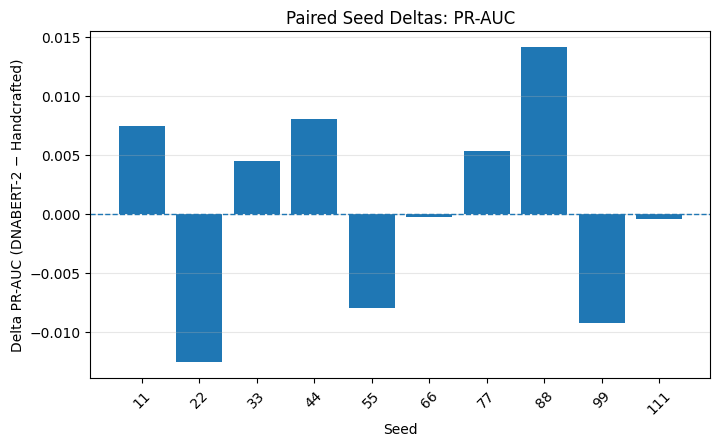

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_paired_delta_pr_auc.png


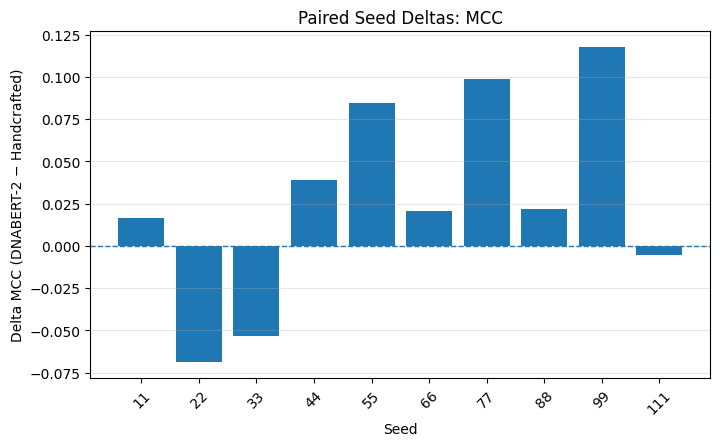

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_paired_delta_mcc.png


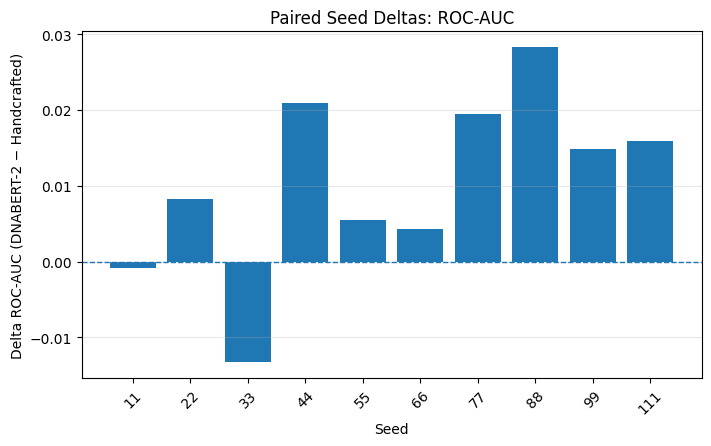

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_paired_delta_roc_auc.png


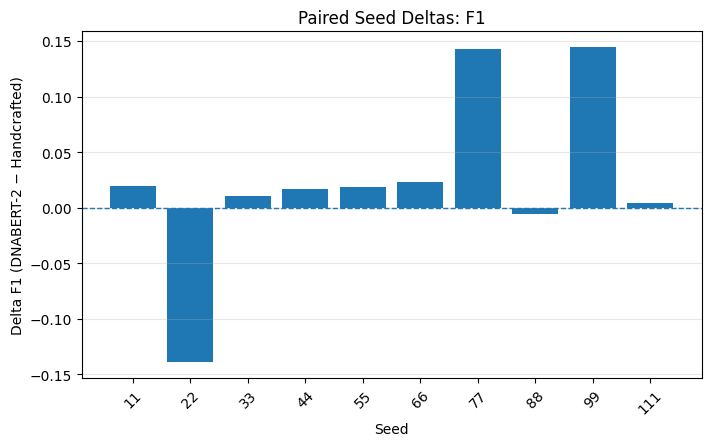

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_paired_delta_f1.png


In [15]:
# ============================================================
# FIGURE 1 — PAIRED DELTA DISTRIBUTIONS
# ============================================================

for metric in METRICS:
    sub = per_seed_delta_df[per_seed_delta_df["metric"] == metric].copy()

    plt.figure(figsize=(8, 4.5))
    plt.bar(
        sub["seed"].astype(str),
        sub["delta_dnabert2_minus_handcrafted"]
    )
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Seed")
    plt.ylabel(f"Delta {METRIC_DISPLAY[metric]} (DNABERT-2 − Handcrafted)")
    plt.title(f"Paired Seed Deltas: {METRIC_DISPLAY[metric]}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

    out_path = FIGURE_DIR / f"phase13_paired_delta_{metric}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

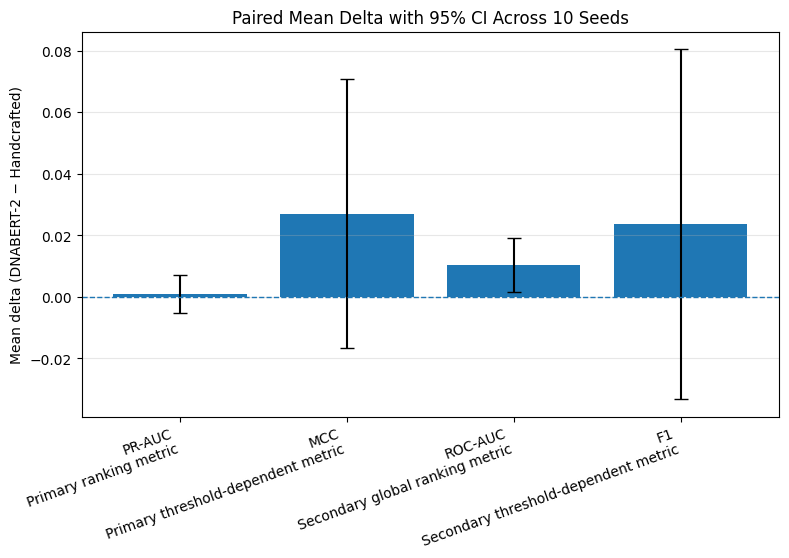

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_paired_mean_delta_95ci.png


In [16]:
# ============================================================
# FIGURE 2 — PAIRED MEAN DELTAS WITH 95% CI
# ============================================================

plot_df = paired_stats_df.copy()
plot_df["metric_label"] = plot_df["metric_display"] + "\n" + plot_df["metric_role"]

x = np.arange(len(plot_df))

mean_delta = plot_df["mean_delta"].values
ci_low = plot_df["t_ci95_low"].values
ci_high = plot_df["t_ci95_high"].values

yerr = np.vstack([
    mean_delta - ci_low,
    ci_high - mean_delta
])

plt.figure(figsize=(9, 5))
plt.bar(x, mean_delta, yerr=yerr, capsize=5)
plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(x, plot_df["metric_label"], rotation=20, ha="right")
plt.ylabel("Mean delta (DNABERT-2 − Handcrafted)")
plt.title("Paired Mean Delta with 95% CI Across 10 Seeds")
plt.grid(axis="y", alpha=0.3)

out_path = FIGURE_DIR / "phase13_paired_mean_delta_95ci.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

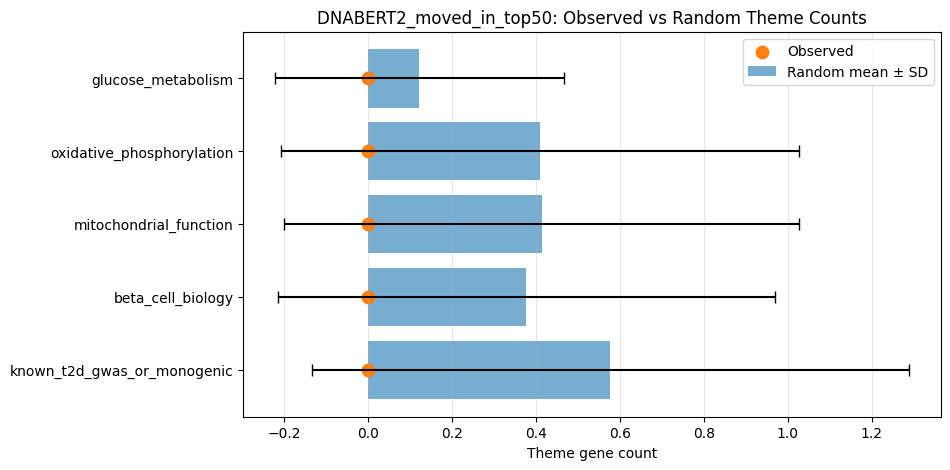

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_DNABERT2_moved_in_top50_observed_vs_random.png


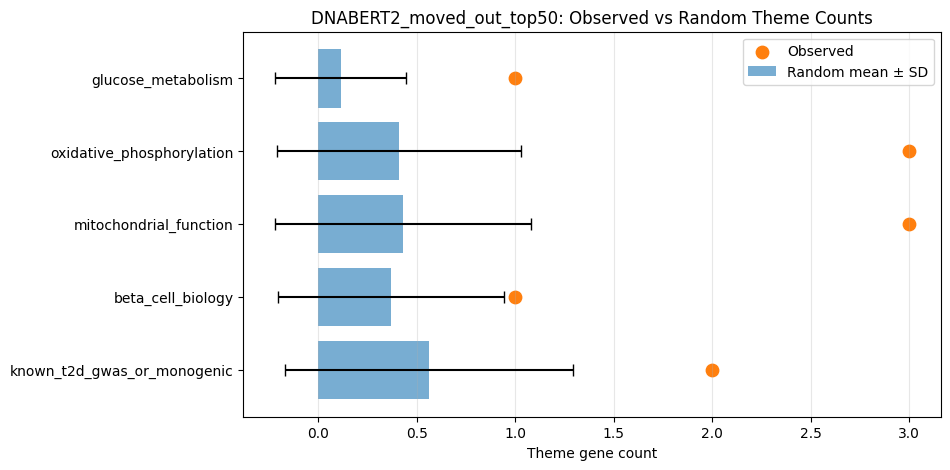

Saved: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/figures/phase13_DNABERT2_moved_out_top50_observed_vs_random.png


In [17]:
# ============================================================
# FIGURE 3 — MOVED-IN / MOVED-OUT TOP50 THEME COUNTS VS RANDOM
# ============================================================

focus_themes = [
    "known_t2d_gwas_or_monogenic",
    "beta_cell_biology",
    "mitochondrial_function",
    "oxidative_phosphorylation",
    "glucose_metabolism"
]

plot_moved_df = moved_random_df[
    (moved_random_df["gene_set_name"].isin([
        "DNABERT2_moved_in_top50",
        "DNABERT2_moved_out_top50"
    ])) &
    (moved_random_df["theme"].isin(focus_themes))
].copy()

plot_moved_df["label"] = plot_moved_df["gene_set_name"].str.replace("DNABERT2_", "", regex=False)

for gene_set_name in ["DNABERT2_moved_in_top50", "DNABERT2_moved_out_top50"]:
    sub = plot_moved_df[plot_moved_df["gene_set_name"] == gene_set_name].copy()
    sub = sub.set_index("theme").loc[focus_themes].reset_index()

    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    plt.barh(
        y,
        sub["random_mean"],
        xerr=sub["random_sd"],
        capsize=4,
        alpha=0.6,
        label="Random mean ± SD"
    )
    plt.scatter(
        sub["observed_count"],
        y,
        s=80,
        label="Observed"
    )

    plt.yticks(y, sub["theme"])
    plt.xlabel("Theme gene count")
    plt.title(f"{gene_set_name}: Observed vs Random Theme Counts")
    plt.legend()
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / f"phase13_{gene_set_name}_observed_vs_random.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [18]:
# ============================================================
# EXPORT PHASE 13 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase13_statistical_and_claim_calibration_tables.xlsx"

excel_tables = {
    "Per_Seed_Deltas": per_seed_delta_df,
    "Paired_Stats": paired_stats_df,
    "Report_Paired_Table": report_paired_stats_df,
    "Sign_Test_Reference": sign_test_reference_df,
    "Moved_Definition": moved_definition_df,
    "Moved_In_Top50": moved_in_top50_summary_df,
    "Moved_Out_Top50": moved_out_top50_summary_df,
    "Calibrated_Bio_Claims": calibrated_bio_claims_df,
    "Revised_Wording": revised_wording_df,
    "Main_Claims": main_claims_df,
    "Phase12_Focus": focus_df,
    "Phase12_Moved_Random": moved_random_df,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/excel/phase13_statistical_and_claim_calibration_tables.xlsx


In [19]:
# ============================================================
# AUTO-GENERATE PHASE 13 REPORT SUMMARY
# ============================================================

paired_table_markdown = report_paired_stats_df.to_markdown(index=False)

report_lines = []

report_lines.append("# Phase 13 — Statistical and Claim Calibration")
report_lines.append("")
report_lines.append("## Objective")
report_lines.append("")
report_lines.append(
    "This phase addresses the latest feedback by replacing unpaired-style interpretation of the repeated-split evaluation "
    "with paired statistical tests, and by calibrating the biological interpretation to match the FDR-corrected evidence."
)
report_lines.append("")
report_lines.append("## Paired Seed Comparison")
report_lines.append("")
report_lines.append(
    "Because the repeated-split evaluation used the same random seeds for each model, model differences were analysed as paired deltas:"
)
report_lines.append("")
report_lines.append("delta_i = metric_DNABERT2(seed_i) − metric_handcrafted(seed_i)")
report_lines.append("")
report_lines.append("The primary paired test was the Wilcoxon signed-rank test. Paired t-tests and exact sign tests were included as supportive checks. BH-FDR correction was applied across the four Wilcoxon tests.")
report_lines.append("")
report_lines.append(paired_table_markdown)
report_lines.append("")
report_lines.append("## Calibrated Statistical Interpretation")
report_lines.append("")
report_lines.append(
    "Across 10 paired splits, DNABERT-2 showed numerically higher ROC-AUC, MCC and F1 and essentially tied PR-AUC. "
    "However, the paired tests did not establish statistically significant superiority after BH correction. "
    "Therefore, DNABERT-2 should be described as showing a small, directionally repeatable but not statistically established global-ranking advantage."
)
report_lines.append("")
report_lines.append("## Moved-in / Moved-out Comparator")
report_lines.append("")
report_lines.append(
    "Moved-in and moved-out genes were defined relative to the handcrafted multimodal ranking. "
    "Moved-in genes are inside DNABERT-2 top-N but outside handcrafted top-N. "
    "Moved-out genes are inside handcrafted top-N but outside DNABERT-2 top-N."
)
report_lines.append("")
report_lines.append("## Moved-in Top-50 Baseline")
report_lines.append("")
report_lines.append(
    "DNABERT-2 moved-in top-50 genes contained zero genes across the curated T2D, beta-cell, glucose, mitochondrial/OXPHOS, insulin-signalling, pancreatic-development and lipid-metabolism themes. "
    "Same-size random baselines show that these low-frequency themes often have low or zero counts in random sets. "
    "Therefore, this should be interpreted as absence of curated-theme enrichment, not as statistically significant depletion."
)
report_lines.append("")
report_lines.append("## Moved-out Top-50 Baseline")
report_lines.append("")
report_lines.append(
    f"The moved-out top-50 genes contained {int(moved_out_mito['observed_count'])} mitochondrial-function genes "
    f"({moved_out_mito['observed_genes']}) compared with random mean {moved_out_mito['random_mean']:.3f} ± {moved_out_mito['random_sd']:.3f} "
    f"(empirical p={moved_out_mito['empirical_p_greater_equal']:.4f}, FDR p={moved_out_mito['empirical_p_bh_fdr']:.4f}). "
    f"They also contained {int(moved_out_oxphos['observed_count'])} OXPHOS genes "
    f"({moved_out_oxphos['observed_genes']}) compared with random mean {moved_out_oxphos['random_mean']:.3f} ± {moved_out_oxphos['random_sd']:.3f} "
    f"(empirical p={moved_out_oxphos['empirical_p_greater_equal']:.4f}, FDR p={moved_out_oxphos['empirical_p_bh_fdr']:.4f}). "
    "These results are nominally enriched but not FDR-significant, so they should be treated as hypothesis-generating."
)
report_lines.append("")
report_lines.append("## Revised Central Interpretation")
report_lines.append("")
report_lines.append(
    "The calibrated interpretation is that the results are consistent with a ranking-versus-interpretability trade-off. "
    "DNABERT-2 shows small, directionally repeatable numerical gains in several metrics but not statistically established superiority after paired testing and BH correction. "
    "Meanwhile, handcrafted/protein rankings show suggestive mitochondrial/OXPHOS concentration among top candidates, but the biological evidence is FDR-borderline and based on small gene counts. "
    "Therefore, the trade-off should be presented as a central hypothesis-generating finding rather than a definitive effect."
)

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "phase13_statistical_and_claim_calibration_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("\nSaved:", report_path)

# Phase 13 — Statistical and Claim Calibration

## Objective

This phase addresses the latest feedback by replacing unpaired-style interpretation of the repeated-split evaluation with paired statistical tests, and by calibrating the biological interpretation to match the FDR-corrected evidence.

## Paired Seed Comparison

Because the repeated-split evaluation used the same random seeds for each model, model differences were analysed as paired deltas:

delta_i = metric_DNABERT2(seed_i) − metric_handcrafted(seed_i)

The primary paired test was the Wilcoxon signed-rank test. Paired t-tests and exact sign tests were included as supportive checks. BH-FDR correction was applied across the four Wilcoxon tests.

| Metric                                    |   Mean Δ D2−HC | 95% CI of Δ       | Bootstrap 95% CI   |   Wilcoxon p |   Wilcoxon BH-FDR p |   Paired t-test p |   Sign-test p |   Wins D2/10 |   Wins HC/10 | Δ range           |   Cohen dz |   Rank-biserial r | Interpretation            

In [20]:
# ============================================================
# LIST PHASE 13 OUTPUTS
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_calibrated_biological_claims.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_exact_sign_test_reference_n10.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_main_calibrated_claims_for_professor.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_in_out_comparator_definition.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_in_top50_random_baseline_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_moved_out_top50_random_baseline_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_paired_seed_statistics_d

In [21]:
display(report_paired_stats_df)
display(paired_stats_df)
display(moved_in_top50_summary_df)
display(moved_out_top50_summary_df)
display(calibrated_bio_claims_df)
display(revised_wording_df)
display(main_claims_df)

,Metric,Mean Δ D2−HC,95% CI of Δ,Bootstrap 95% CI,Wilcoxon p,Wilcoxon BH-FDR p,Paired t-test p,Sign-test p,Wins D2/10,Wins HC/10,Δ range,Cohen dz,Rank-biserial r,Interpretation
0,PR-AUC (Primary ranking metric),0.0009,"[-0.0053, 0.0070]","[-0.0042, 0.0059]",0.9434,0.9434,0.7595,1.0000,5,5,-0.0126 to 0.0141,0.0998,0.0364,"PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. This supports comparable primary ranking performance, not DNABERT-2 superiority."
1,MCC (Primary threshold-dependent metric),0.0271,"[-0.0167, 0.0709]","[-0.0088, 0.0633]",0.1934,0.2578,0.1954,0.3438,7,3,-0.0689 to 0.1175,0.4423,0.4909,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
2,ROC-AUC (Secondary global ranking metric),0.0103,"[0.0017, 0.0190]","[0.0030, 0.0173]",0.0273,0.1094,0.0242,0.1094,8,2,-0.0133 to 0.0283,0.8552,0.7818,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
3,F1 (Secondary threshold-dependent metric),0.0236,"[-0.0332, 0.0805]","[-0.0216, 0.0682]",0.0840,0.1680,0.3718,0.1094,8,2,-0.1392 to 0.1445,0.2972,0.6364,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."


,metric,metric_display,metric_role,n_paired_seeds,mean_delta,median_delta,sd_delta,t_ci95_low,t_ci95_high,bootstrap_ci95_low,bootstrap_ci95_high,min_delta,max_delta,n_dnabert2_better,n_handcrafted_better,n_ties,wilcoxon_statistic,wilcoxon_p,paired_t_statistic,paired_t_p,exact_sign_test_p,cohen_dz,rank_biserial_correlation,delta_values,wilcoxon_p_bh_fdr,paired_t_p_bh_fdr,sign_test_p_bh_fdr,wilcoxon_significant_fdr_0p05,paired_t_significant_fdr_0p05,sign_test_significant_fdr_0p05,calibrated_interpretation
0,pr_auc,PR-AUC,Primary ranking metric,10,0.00086,0.00210,0.008616,-0.005303,0.007023,-0.004190,0.005870,-0.0126,0.0141,5,5,0,26.5,0.943359,0.315644,0.759469,1.000000,0.099815,0.036364,0.007400;-0.012600;0.004500;0.008000;-0.008000;-0.000300;0.005300;0.014100;-0.009300;-0.000500,0.943359,0.759469,1.000000,False,False,False,"PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. This supports comparable primary ranking performance, not DNABERT-2 superiority."
1,mcc,MCC,Primary threshold-dependent metric,10,0.02708,0.02110,0.061226,-0.016718,0.070878,-0.008813,0.063260,-0.0689,0.1175,7,3,0,14.0,0.193359,1.398672,0.195414,0.343750,0.442299,0.490909,0.016600;-0.068900;-0.053500;0.039200;0.084600;0.020400;0.098800;0.021800;0.117500;-0.005700,0.257812,0.390828,0.458333,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
2,roc_auc,ROC-AUC,Secondary global ranking metric,10,0.01034,0.01155,0.012091,0.001690,0.018990,0.003030,0.017250,-0.0133,0.0283,8,2,0,6.0,0.027344,2.704246,0.024225,0.109375,0.855158,0.781818,-0.000800;0.008300;-0.013300;0.020900;0.005500;0.004300;0.019500;0.028300;0.014800;0.015900,0.109375,0.096899,0.218750,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
3,f1,F1,Secondary threshold-dependent metric,10,0.02363,0.01790,0.079495,-0.033238,0.080498,-0.021600,0.068161,-0.1392,0.1445,8,2,0,10.0,0.083984,0.939987,0.371766,0.109375,0.297250,0.636364,0.019400;-0.139200;0.010200;0.017200;0.018600;0.023500;0.143100;-0.005500;0.144500;0.004500,0.167969,0.495688,0.218750,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."


,gene_set_name,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_p025,random_p975,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,empirical_p_bh_fdr,significant_empirical_p_0p05,significant_fdr_0p05,calibrated_interpretation
0,DNABERT2_moved_in_top50,11,insulin_signalling,0,0.0,NaN,0.039,0.1937,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
1,DNABERT2_moved_in_top50,11,glucose_metabolism,0,0.0,NaN,0.123,0.3435,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
2,DNABERT2_moved_in_top50,11,beta_cell_biology,0,0.0,NaN,0.378,0.5912,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
3,DNABERT2_moved_in_top50,11,mitochondrial_function,0,0.0,NaN,0.414,0.6124,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
4,DNABERT2_moved_in_top50,11,oxidative_phosphorylation,0,0.0,NaN,0.411,0.6168,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
5,DNABERT2_moved_in_top50,11,pancreatic_development,0,0.0,NaN,0.149,0.3807,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
6,DNABERT2_moved_in_top50,11,lipid_metabolism,0,0.0,NaN,0.033,0.1787,0.0,1.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."
7,DNABERT2_moved_in_top50,11,known_t2d_gwas_or_monogenic,0,0.0,NaN,0.578,0.7116,0.0,2.0,0.0,1.0,1.0,False,False,"No curated-theme genes observed. This indicates the moved-in genes are not theme-enriched under the current curated framework; because random same-size sets often also contain few or zero theme genes, this should be interpreted as absence of enrichment rather than statistically significant depletion."


,gene_set_name,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_p025,random_p975,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,empirical_p_bh_fdr,significant_empirical_p_0p05,significant_fdr_0p05,calibrated_interpretation
8,DNABERT2_moved_out_top50,11,insulin_signalling,0,0.0000,NaN,0.042,0.2007,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
9,DNABERT2_moved_out_top50,11,glucose_metabolism,1,0.0909,SLC5A1,0.113,0.3322,0.0,1.0,8.8496,0.1089,0.5808,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.
10,DNABERT2_moved_out_top50,11,beta_cell_biology,1,0.0909,DPP4,0.368,0.5735,0.0,2.0,2.7174,0.3217,1.0000,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.
11,DNABERT2_moved_out_top50,11,mitochondrial_function,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.430,0.6477,0.0,2.0,6.9767,0.0100,0.1598,True,False,"Observed theme count is nominally enriched but does not survive FDR correction; interpret as hypothesis-generating, especially given small gene counts."
12,DNABERT2_moved_out_top50,11,oxidative_phosphorylation,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.410,0.6183,0.0,2.0,7.3171,0.0070,0.1598,True,False,"Observed theme count is nominally enriched but does not survive FDR correction; interpret as hypothesis-generating, especially given small gene counts."
13,DNABERT2_moved_out_top50,11,pancreatic_development,0,0.0000,NaN,0.180,0.4216,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
14,DNABERT2_moved_out_top50,11,lipid_metabolism,0,0.0000,NaN,0.042,0.2007,0.0,1.0,0.0000,1.0000,1.0000,False,False,Observed theme count is not above random baseline.
15,DNABERT2_moved_out_top50,11,known_t2d_gwas_or_monogenic,2,0.1818,DPP4;SLC5A1,0.564,0.7311,0.0,2.0,3.5461,0.1069,0.5808,False,False,Observed count is above random mean but not statistically supported; interpret only descriptively.


,model_key,top_n,theme,observed_count,random_mean,random_sd,enrichment_ratio,empirical_p,fdr_p,claim_strength,calibrated_interpretation
0,Multimodal_handcrafted,100,mitochondrial_function,7,3.694,1.5161,1.8950,0.0380,0.1158,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
1,Multimodal_handcrafted,100,oxidative_phosphorylation,7,3.694,1.5161,1.8950,0.0380,0.1158,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
2,Multimodal_DNABERT2,100,mitochondrial_function,6,3.694,1.5161,1.6243,0.1299,0.3058,Descriptive only,Observed count should be described descriptively and not claimed as enriched.
3,Multimodal_DNABERT2,100,oxidative_phosphorylation,6,3.694,1.5161,1.6243,0.1299,0.3058,Descriptive only,Observed count should be described descriptively and not claimed as enriched.
4,Protein_only_ProtBERT_SW,100,mitochondrial_function,8,3.694,1.5161,2.1657,0.0060,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
5,Protein_only_ProtBERT_SW,100,oxidative_phosphorylation,8,3.694,1.5161,2.1657,0.0060,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
6,Multimodal_handcrafted,100,known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
7,Multimodal_DNABERT2,100,known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
8,Multimodal_handcrafted,100,beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."
9,Multimodal_DNABERT2,100,beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Nominal / FDR-borderline,"Can be described as supportive or hypothesis-generating evidence, but not as confirmed enrichment after correction."


,section,revised_text
0,Section 5 — Paired seed comparison,"Across 10 paired repeated splits, DNABERT-2 showed numerically higher ROC-AUC, MCC and F1 than the handcrafted multimodal model, while PR-AUC was essentially tied. PR-AUC: mean Δ=0.0009, 95% CI [-0.0053, 0.0070], Wilcoxon p=0.9434, BH-FDR p=0.9434, wins DNABERT-2=5/10. MCC: mean Δ=0.0271, 95% CI [-0.0167, 0.0709], Wilcoxon p=0.1934, BH-FDR p=0.2578, wins DNABERT-2=7/10. ROC-AUC: mean Δ=0.0103, 95% CI [0.0017, 0.0190], Wilcoxon p=0.0273, BH-FDR p=0.1094, wins DNABERT-2=8/10. F1: mean Δ=0.0236..."
1,Section 10.1 — DNABERT-2 moved-in top-50 genes,"Moved-in genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside the DNABERT-2 top-50 but outside the handcrafted multimodal top-50. These DNABERT-2 moved-in top-50 genes contained zero members of the curated T2D, beta-cell, glucose, mitochondrial/OXPHOS, insulin-signalling, pancreatic-development and lipid-metabolism themes. Same-size random sets sampled from the 271-gene universe were used as a baseline. Because random sets often contain few or zero ..."
2,Section 10.2 — DNABERT-2 moved-out top-50 genes,"Moved-out genes were defined relative to the handcrafted multimodal ranking: they are genes ranked inside the handcrafted multimodal top-50 but outside the DNABERT-2 top-50. The moved-out top-50 genes contained 3 mitochondrial-function genes (NDUFA7;NDUFB1;NDUFB3) compared with a random mean of 0.430 ± 0.648 (empirical p=0.0100, FDR p=0.1598), and 3 oxidative-phosphorylation genes (NDUFA7;NDUFB1;NDUFB3) compared with a random mean of 0.410 ± 0.618 (empirical p=0.0070, FDR p=0.1598). These fi..."
3,Section 11 — Integrated interpretation,"Taken together, the repeated-split and random-baseline analyses are consistent with a ranking-versus-interpretability trade-off. DNABERT-2 shows small, directionally repeatable numerical gains in ROC-AUC, MCC and F1, but the paired differences are not statistically significant after BH correction and PR-AUC is essentially tied. Biologically, the handcrafted and protein-based rankings show higher raw mitochondrial/OXPHOS counts among top-ranked candidates than DNABERT-2, but these patterns ar..."


,claim_area,previous_risk,new_analysis,calibrated_claim
0,Repeated-split paired statistics,Mean ± SD and win counts were not enough because the design is paired.,"Wilcoxon signed-rank test, paired t-test, exact sign test and BH-FDR were applied to per-seed deltas.","DNABERT-2 shows numerically higher ROC-AUC, MCC and F1, but paired differences are not statistically established after correction. PR-AUC is essentially tied."
1,Metric hierarchy,Different models could be described as winning different metrics.,"PR-AUC is treated as primary ranking metric, MCC as primary threshold metric, ROC-AUC/F1 as secondary.",Model interpretation prioritises PR-AUC and MCC while treating ROC-AUC and F1 as secondary supporting metrics.
2,Moved-in comparator,Moved-in/out language was ambiguous without comparator.,Moved-in and moved-out are explicitly defined relative to handcrafted multimodal top-N ranking.,Moved-in genes are inside DNABERT-2 top-N but outside handcrafted top-N; moved-out genes are inside handcrafted top-N but outside DNABERT-2 top-N.
3,Moved-in random baseline,0 curated themes in moved-in genes needed comparison to random expectation.,Same-size random baseline was reported for moved-in top-50 genes.,"DNABERT-2 moved-in top-50 genes are not enriched for curated T2D themes under the current framework; this is absence of enrichment, not proof of significant depletion."
4,Moved-out mitochondrial/OXPHOS,Language suggested confirmatory biological displacement despite FDR-borderline evidence.,Moved-out empirical p-values and FDR p-values are reported directly.,Moved-out top-50 mitochondrial/OXPHOS genes are nominally enriched but not FDR-significant; the pattern is hypothesis-generating.
5,Central narrative,Could be read as claiming DNABERT-2 superiority or confirmed biological displacement.,Reframed as ranking-versus-interpretability trade-off with statistical and FDR caveats.,"DNABERT-2 may offer a small directional global-ranking extension, while handcrafted/protein rankings show suggestive mitochondrial/OXPHOS specificity; this is the central hypothesis-generating result."
